<a href="https://colab.research.google.com/github/mitparekh8263/CV-2026-H11/blob/main/Practical_05/lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
image = cv2.imread("tiger.jpg", cv2.IMREAD_GRAYSCALE)
image.shape

(364, 549)

In [ ]:
def sobel_filter(image) :

  sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
  sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])

  row, col = image.shape

  padded = np.pad(image, 1, mode='constant')

  gx = np.zeros((row, col), dtype=np.float32)
  gy = np.zeros((row, col), dtype=np.float32)
  output = np.zeros((row, col), dtype=np.float32)

  for i in range(row) :
    for j in range(col) :

      sum_x = 0
      sum_y = 0

      for k in range(3) :
        for l in range(3) :

          pixel = float(padded[i+k][j+l])

          sum_x = sum_x + pixel * sobel_x[k][l]
          sum_y = sum_y + pixel * sobel_y[k][l]

      gx[i][j] = sum_x
      gy[i][j] = sum_y

      output[i][j] = np.sqrt(sum_x**2 + sum_y**2)

  output = np.clip(output, 0, 255)

  return gx, gy, output.astype(np.uint8)

In [ ]:
gx, gy, edge_image = sobel_filter(image)

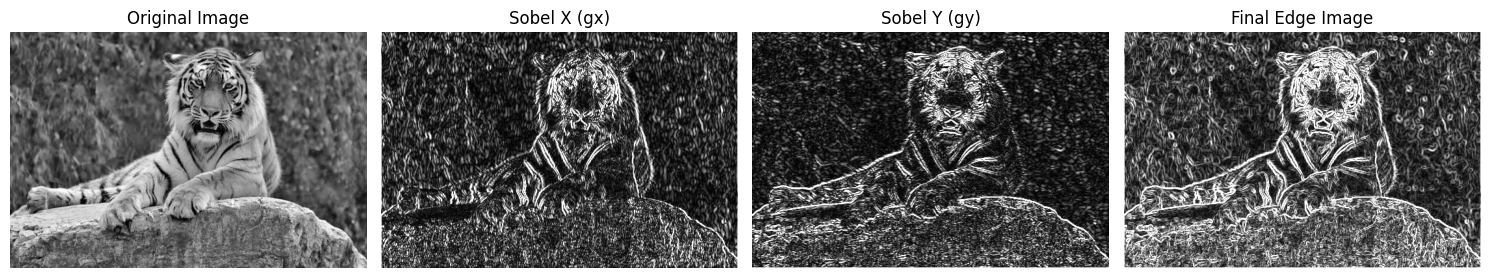

In [ ]:
plt.figure(figsize=(15, 5))

# 1. Original Grayscale Image
plt.subplot(1, 4, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# 2. Sobel X Gradient (Horizontal Edges)
plt.subplot(1, 4, 2)
plt.imshow(np.clip(np.abs(gx), 0, 255).astype(np.uint8), cmap='gray')
plt.title('Sobel X (gx)')
plt.axis('off')

# 3. Sobel Y Gradient (Vertical Edges)
plt.subplot(1, 4, 3)
plt.imshow(np.clip(np.abs(gy), 0, 255).astype(np.uint8), cmap='gray')
plt.title('Sobel Y (gy)')
plt.axis('off')

# 4. Final Gradient Magnitude (Edge Image)
plt.subplot(1, 4, 4)
plt.imshow(edge_image, cmap='gray')
plt.title('Final Edge Image')
plt.axis('off')

# Adjust layout to prevent overlap and render the plot
plt.tight_layout()
plt.show()
